# H1 = Shortstops are taller than second basemen

In [1]:
import pandas as pd
df = pd.read_table('../../data/SOCR_MLB.tsv')
df.head()

,Adam_Donachie,BAL,Catcher,74,180,22.99
0,Paul_Bako,BAL,Catcher,74,215.0,34.69
1,Ramon_Hernandez,BAL,Catcher,72,210.0,30.78
2,Kevin_Millar,BAL,First_Baseman,72,210.0,35.43
3,Chris_Gomez,BAL,First_Baseman,73,188.0,35.71
4,Brian_Roberts,BAL,Second_Baseman,69,176.0,29.39


In [2]:
df.columns = ['Name', 'Team', 'Role', 'Weight', 'Height', 'Age']
df.head()

,Name,Team,Role,Weight,Height,Age
0,Paul_Bako,BAL,Catcher,74,215.0,34.69
1,Ramon_Hernandez,BAL,Catcher,72,210.0,30.78
2,Kevin_Millar,BAL,First_Baseman,72,210.0,35.43
3,Chris_Gomez,BAL,First_Baseman,73,188.0,35.71
4,Brian_Roberts,BAL,Second_Baseman,69,176.0,29.39


In [3]:
df.groupby('Role').agg(
    Mean_Height=('Height', 'mean'),
    Count=('Age', 'count')
)

,Mean_Height,Count
Role,,
Catcher,204.653333,75
Designated_Hitter,220.888889,18
First_Baseman,213.109091,55
Outfielder,199.113402,194
Relief_Pitcher,203.517460,315
Second_Baseman,184.344828,58
Shortstop,182.923077,52
Starting_Pitcher,205.163636,221
Third_Baseman,200.955556,45


In [4]:
import numpy as np
import scipy.stats

In [5]:
def mean_confidence_interval(data, confidence=0.95):
    a = 1.0 * data
    n = len(a)
    m, se = np.mean(a), scipy.stats.sem(a)
    h = se * scipy.stats.t.ppf((1+confidence)/2, n-1)
    return m, h

In [6]:
for p in [0.85, 0.9, 0.95]:
    m1, h1 = mean_confidence_interval(df.loc[df['Role'] == 'Shortstop', ['Height']], p)
    m2, h2 = mean_confidence_interval(df.loc[df['Role'] == 'Second_Baseman', ['Height']], p)
    print(f"p: {p:.2f}, Shortstop's Height: {m1-h1[0]:.2f}..{m1+h1[0]:.2f}, 2nd Basemen's Height: {m2-h2[0]:.2f}..{m2+h2[0]:.2f}")

p: 0.85, Shortstop's Height: 179.98..185.86, 2nd Basemen's Height: 182.24..186.45
p: 0.90, Shortstop's Height: 179.55..186.29, 2nd Basemen's Height: 181.93..186.76
p: 0.95, Shortstop's Height: 178.89..186.96, 2nd Basemen's Height: 181.45..187.24


In [7]:
from scipy.stats import ttest_ind

In [8]:
tval, pval = ttest_ind(df.loc[df['Role'] == 'Shortstop', ['Height']], df.loc[df['Role'] == 'Second_Baseman', ['Height']], equal_var=False)
print(f"t-value: {tval[0]:.2f}, p-value: {pval[0]:.2f}")

t-value: -0.57, p-value: 0.57


> Since t-value is -ve, it suggests that shortstops are actually shorter than second basemen.

> and, Since p-value is above threshold (0.05), therefore, we accept H1

In [18]:
import matplotlib.pyplot as plt

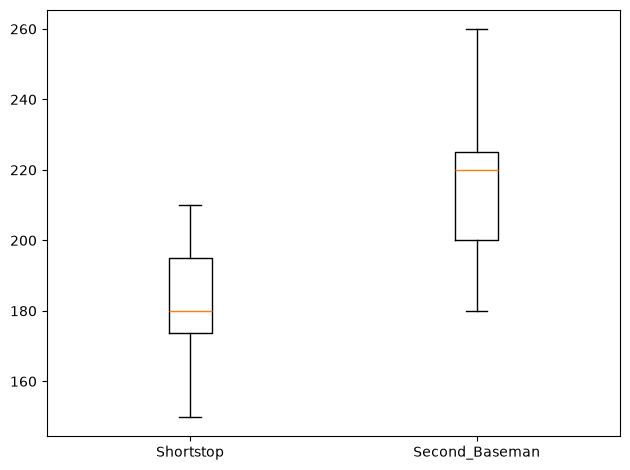

In [27]:
shortstops = df[df['Role'] == 'Shortstop']['Height']
second_baseman = df[df['Role'] == 'First_Baseman']['Height']

plt.boxplot([shortstops, second_baseman])
plt.tight_layout()
plt.xticks([1, 2], ['Shortstop', 'Second_Baseman'])
plt.show()